In [1]:
import os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')  # evita OOM por fragmentacao na GPU de 6GB

import torch, torchvision
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import cv2, shutil, glob, json, math, datetime, random, gc
import numpy as np
import pandas as pd
import torch.nn as nn
from tqdm import tqdm
from utils.index import *

from torch.utils.data import DataLoader, Dataset
from torchvision.ops import nms
import albumentations as A

from utils.Plotter.index import Plotter
pd.set_option('display.max_columns', None)

In [2]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versao do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU

2.7.1+cu118
True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print('done')


seed_everything(42)

done


In [4]:
OPTIONS = json.loads(open('../Task/info.json', 'r').read())
OPTIONS

{'dataset': 'Aquisition',
 'network': 'fasterrcnn',
 'img_size': 512,
 'n_aug': 1,
 'lr': 0.0001,
 'loss': 'classifier',
 'batch_size': 4,
 'scheduler': 'plateau',
 'epochs': 50,
 'score_threshold': 0.5,
 'nms_threshold': 0.3,
 'val_size': 0.1,
 'test_size': 0.1,
 'n_images': 0}

In [5]:
IMG_SIZE   = OPTIONS.get('img_size')
BATCH_SIZE = OPTIONS.get('batch_size')
N_AUG      = OPTIONS.get('n_aug', 0)

SCORE_THRESHOLD = OPTIONS.get('score_threshold')
NMS_THRESHOLD   = OPTIONS.get('nms_threshold')

IMG_SIZE, BATCH_SIZE, N_AUG

(512, 4, 1)

In [6]:
df = pd.read_csv('../Dataset/DataBase.csv')
df['path'] = [os.path.join('../Dataset', path) for path in df.path]
print(df.path.iloc[0])
df

../Dataset/Aquisition/files/green/Screenshot from 2026-05-19 11-28-40.png


,path,label,x_min,y_min,x_max,y_max
0,../Dataset/Aquisition/files/green/Screenshot f...,green,160,173,369,576
1,../Dataset/Aquisition/files/green/Screenshot f...,green,184,239,382,633
2,../Dataset/Aquisition/files/green/Screenshot f...,green,126,161,324,553
3,../Dataset/Aquisition/files/green/Screenshot f...,green,183,195,380,581
4,../Dataset/Aquisition/files/green/Screenshot f...,green,192,241,387,628
...,...,...,...,...,...,...
79,../Dataset/Aquisition/files/yellow/Screenshot ...,yellow,168,236,367,611
80,../Dataset/Aquisition/files/yellow/Screenshot ...,yellow,704,161,894,541
81,../Dataset/Aquisition/files/yellow/Screenshot ...,yellow,835,276,1039,646
82,../Dataset/Aquisition/files/yellow/Screenshot ...,yellow,406,171,590,554


In [7]:
classes = {label: (i + 1) for i, label in enumerate(sorted(df.label.unique()))}
names   = {value: label for label, value in classes.items()}

df['value'] = df.label.map(classes)
classes

{'green': 1, 'red': 2, 'yellow': 3}

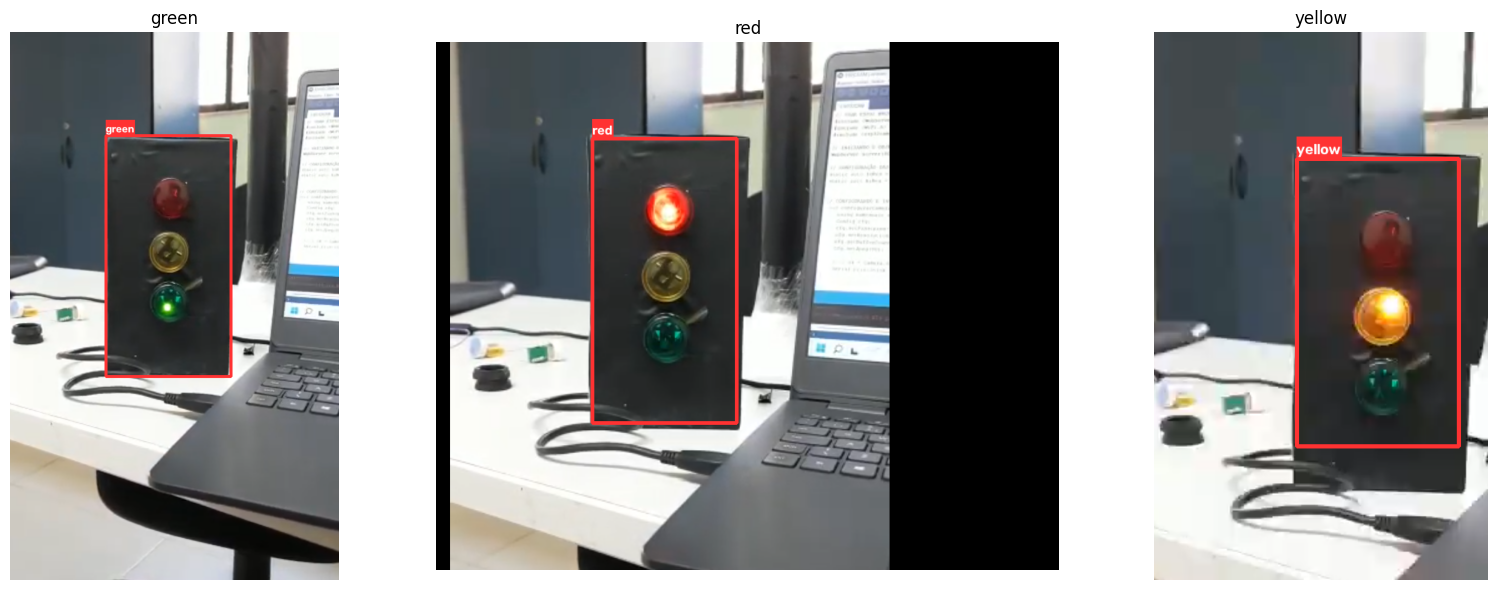

In [8]:
plt.figure(figsize=(18, 6))
for i, label in enumerate(classes):
    row = df[df.label == label].iloc[0]
    img = drawBox(loadImage(row.path), (row.x_min, row.y_min, row.x_max, row.y_max), row.label, (255, 50, 50), thickness=4)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img); plt.title(row.label); plt.axis('off')

plt.tight_layout()
plt.show()

# SPLITS DOS DADOS

In [9]:
VAL_SIZE  = OPTIONS.get('val_size')
TEST_SIZE = OPTIONS.get('test_size')
VAL_FRAC  = VAL_SIZE / (1 - TEST_SIZE)

In [10]:
temp_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=42, stratify=df.label)
train_df, val_df = train_test_split(temp_df, test_size=VAL_FRAC, random_state=42, stratify=temp_df.label)
del temp_df

OPTIONS['n_images'] = {'total': len(df), 'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}
OPTIONS['n_images']

{'total': 84, 'train': 66, 'val': 9, 'test': 9}

# MODELO

In [11]:
from Network.index import ModelNetwork

In [12]:
model_options = {
    'network': OPTIONS.get('network'),
    'img_size': OPTIONS.get('img_size'),
    'classes': len(classes) + 1,
    'channels': 3,
    'lr': OPTIONS.get('lr'),
    'score_threshold': SCORE_THRESHOLD,
}

print(model_options)
network = ModelNetwork(**model_options)
network.model

{'network': 'fasterrcnn', 'img_size': 512, 'classes': 4, 'channels': 3, 'lr': 0.0001, 'score_threshold': 0.5}


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [13]:
network.classes

4

# DATASET

In [14]:
from Augmentation.index import Augmentation


class CustomDataset(Dataset):
    def __init__(self, df, img_size, augment=0):
        self.df    = df.reset_index(drop=True)
        self.paths = self.df.path.unique()
        self.img_size = img_size
        self.aug = Augmentation(img_size, augment)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path   = self.paths[index]
        rows   = self.df[self.df.path == path]
        image  = loadImage(path).astype(np.float32) / 255.0
        boxes  = rows[['x_min', 'y_min', 'x_max', 'y_max']].values
        labels = rows['value'].values.astype(np.int64)

        sample = self.aug(image=image, bboxes=boxes, labels=labels)
        boxes  = torch.as_tensor(np.array(sample['bboxes']), dtype=torch.float32).reshape(-1, 4)
        labels = torch.as_tensor(np.array(sample['labels']), dtype=torch.int64).reshape(-1)
        area   = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        valid  = area > 0

        target = {'boxes': boxes[valid], 'labels': labels[valid], 'area': area[valid], 'iscrowd': torch.zeros_like(labels[valid])}
        return (sample['image'], target, path)


trainDataset = CustomDataset(train_df, IMG_SIZE, augment=N_AUG)
valDataset   = CustomDataset(val_df, IMG_SIZE)
testDataset  = CustomDataset(test_df, IMG_SIZE)

# DATA LOADER

In [15]:
NUM_WORKERS = 2
collate     = lambda batch: tuple(zip(*batch))

trainLoader = DataLoader(trainDataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate, pin_memory=torch.cuda.is_available())
valLoader   = DataLoader(valDataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate, pin_memory=torch.cuda.is_available())
testLoader  = DataLoader(testDataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate, pin_memory=torch.cuda.is_available())

xTrain Shape:  (3, 512, 512)
boxes Shape:   (1, 4)
labels:        ['yellow']


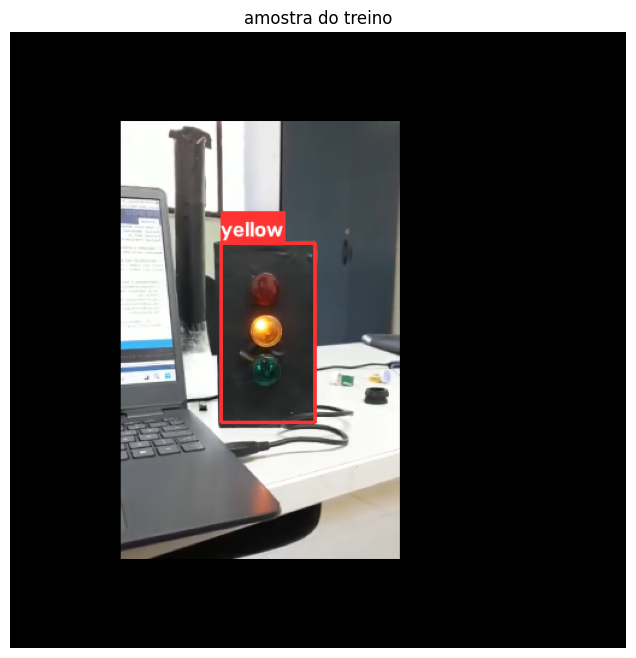

In [16]:
images, targets, paths = next(iter(trainLoader))
img   = np.ascontiguousarray(images[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
boxes = targets[0]['boxes'].cpu().numpy()

print('xTrain Shape: ', tuple(images[0].shape))
print('boxes Shape:  ', tuple(boxes.shape))
print('labels:       ', [names[value] for value in targets[0]['labels'].tolist()])

for box, value in zip(boxes, targets[0]['labels'].tolist()):
    drawBox(img, box, names[value], (255, 50, 50))

plt.figure(figsize=(8, 8))
plt.imshow(img); plt.title('amostra do treino'); plt.axis('off')
plt.show()

# TREINAMENTO

### Losses

In [17]:
from Losses.index import Losses
from EarlyStopping.index import EarlyStopping
from torch import amp
gc.collect()

2389

In [18]:
selected_loss = OPTIONS.get('loss')
loss = Losses(selected_loss)
loss

DetectionWeightedLoss()

### Scheduler

In [19]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [20]:
class Scheduler:
    def __new__(cls, selected, optimizer):
        if selected == 'plateau':
            return ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=6)

        if selected == 'cosine':
            return CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

        return None


scheduler = OPTIONS.get('scheduler')
Scheduler(scheduler, network.optimizer)

### Trainer

In [21]:
class Trainer:
    def __init__(self, network, loss, epochs, scheduler='plateau'):
        self.network  = network
        self.loss     = loss
        self.epochs   = epochs
        self.img_size = network.img_size

        self.scheduler = Scheduler(scheduler, self.network.optimizer)
        self.early_stopping = EarlyStopping(patience=10, mode='max', min_delta=1e-4)

        self.use_amp = True
        self.scaler  = amp.GradScaler('cuda', enabled=self.use_amp)

    def start(self):
        self.history = []

        for epoch in range(1, self.epochs + 1):
            train_loss = self.train()
            val_loss, val_iou = self.evaluate()

            self.history.append({
                'epoch': epoch,
                'train_loss': train_loss, 'val_loss': val_loss,
                'val_iou': val_iou,
                'lr': self.network.optimizer.param_groups[0]['lr'],
            })

            self.scheduler.step(val_loss)
            print(self.history[-1])

            with open('progress.json', 'w', encoding='utf-8') as file:
                json.dump(self.history[-1], file, ensure_ascii=False, indent=4)

            if self.early_stopping.ready(self.network.model, val_iou):
                break

        self.early_stopping.restore_best(self.network.model)

    def train(self, loader=trainLoader):
        self.network.model.train()
        train_loss = 0.0

        for (imgs, targets, paths) in loader:
            imgs    = [img.to(self.network.device) for img in imgs]
            targets = [{key: val.to(self.network.device) for key, val in tgt.items()} for tgt in targets]
            self.network.optimizer.zero_grad()

            with amp.autocast('cuda', enabled=self.use_amp):
                loss_dict = self.network.model(imgs, targets)
                loss = self.loss(loss_dict)

            train_loss += loss.item()
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.network.optimizer)
            torch.nn.utils.clip_grad_norm_(self.network.model.parameters(), max_norm=1.0)
            self.scaler.step(self.network.optimizer)
            self.scaler.update()

        return train_loss / len(loader)

    def evaluate(self, loader=valLoader):
        self.network.iou.reset()
        val_loss = 0.0

        with torch.no_grad():
            for (imgs, targets, paths) in loader:
                imgs    = [img.to(self.network.device) for img in imgs]
                targets = [{key: val.to(self.network.device) for key, val in tgt.items()} for tgt in targets]

                with amp.autocast('cuda', enabled=self.use_amp):
                    self.network.model.train()   # deteccao: o modelo so retorna a loss em modo train
                    loss_dict = self.network.model(imgs, targets)
                    val_loss += self.loss(loss_dict).item()

                    self.network.model.eval()
                    outputs = self.network.model(imgs)

                self.network.iou.update(outputs, targets)

        val_loss /= len(loader)
        val_iou, _ = self.network.iou.compute()
        return (val_loss, val_iou)


trainer = Trainer(network, loss, epochs=OPTIONS.get('epochs'), scheduler=scheduler)
trainer.start()

{'epoch': 1, 'train_loss': 0.8779262944179422, 'val_loss': 0.18986542522907257, 'val_iou': 0.13598210414250692, 'lr': 0.0001}


{'epoch': 2, 'train_loss': 0.22451729020651648, 'val_loss': 0.2792599101861318, 'val_iou': 0.2732148203584883, 'lr': 0.0001}
(early stopping) model improved to 0.2732


{'epoch': 3, 'train_loss': 0.19694466538289013, 'val_loss': 0.15911146501700082, 'val_iou': 0.19084714187516105, 'lr': 0.0001}


{'epoch': 4, 'train_loss': 0.14206551103030934, 'val_loss': 0.12830055256684622, 'val_iou': 0.6538033286730448, 'lr': 0.0001}
(early stopping) model improved to 0.6538


{'epoch': 5, 'train_loss': 0.1125974532435922, 'val_loss': 0.09774411966403325, 'val_iou': 0.7141536540455289, 'lr': 0.0001}
(early stopping) model improved to 0.7142


...

{'epoch': 13, 'train_loss': 0.05566075751010109, 'val_loss': 0.05554508169492086, 'val_iou': 0.7535952428976694, 'lr': 0.0001}


{'epoch': 14, 'train_loss': 0.0459685161271516, 'val_loss': 0.05834123616417249, 'val_iou': 0.9008057663838068, 'lr': 0.0001}


{'epoch': 15, 'train_loss': 0.0467856620602748, 'val_loss': 0.0597185455262661, 'val_iou': 0.8773797121312884, 'lr': 0.0001}


{'epoch': 16, 'train_loss': 0.042806134723565155, 'val_loss': 0.05262993648648262, 'val_iou': 0.8786734789609909, 'lr': 0.0001}


{'epoch': 17, 'train_loss': 0.039114718489787155, 'val_loss': 0.06302669396003087, 'val_iou': 0.9022014985481898, 'lr': 0.0001}


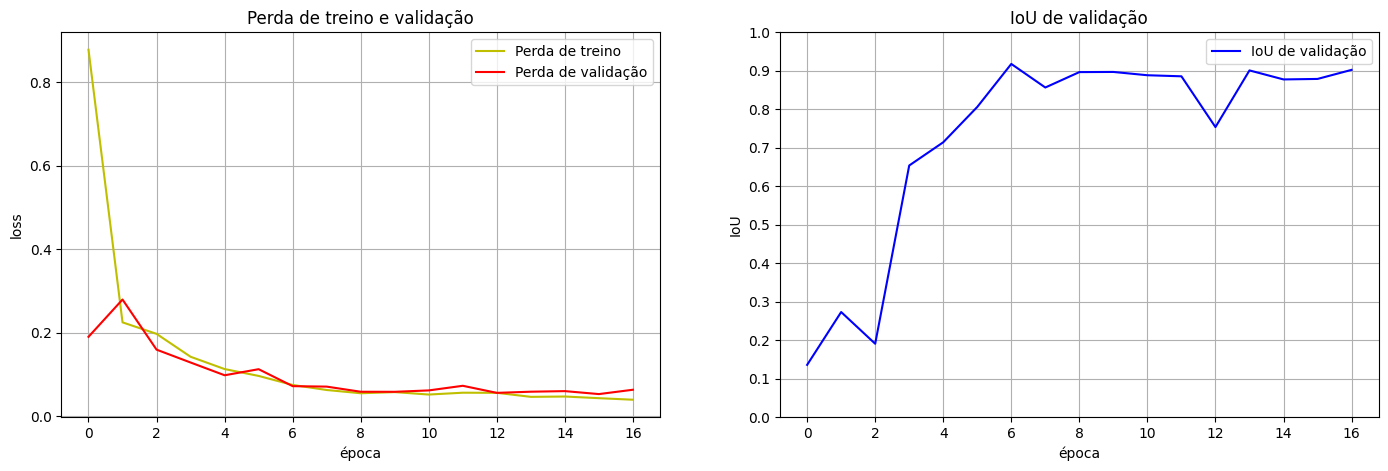

In [22]:
def plotModel(history, save=None):
    plt.figure(figsize=(17, 5))
    plt.subplot(1, 2, 1)
    plt.plot([h.get('train_loss') for h in history], 'y', label='Perda de treino')
    plt.plot([h.get('val_loss') for h in history], 'r', label='Perda de validação')
    plt.title('Perda de treino e validação')
    plt.xlabel('época'), plt.ylabel('loss')
    plt.legend(), plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot([h.get('val_iou') for h in history], 'b', label='IoU de validação')
    plt.title('IoU de validação')
    plt.xlabel('época'), plt.ylabel('IoU')
    plt.legend(), plt.grid(), plt.gca().set_ylim(0, 1), plt.yticks([c / 10 for c in range(11)])

    if not save:
        return plt.show()

    os.makedirs(os.path.dirname(save), exist_ok=True)
    plt.savefig(save, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()


plotModel(trainer.history)

# DADOS DE TESTE

In [23]:
test_loss, test_iou = trainer.evaluate(loader=testLoader)
test_iou

0.8655967464049658

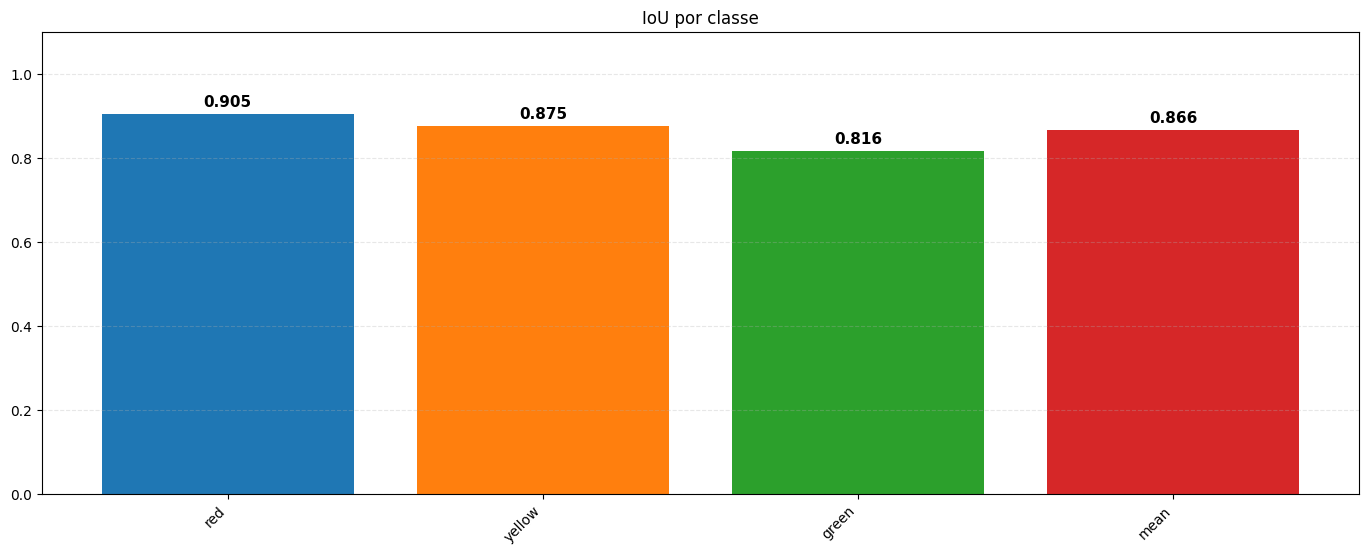

In [24]:
def getClasses(network, loader, save=None):
    network.model.eval()
    network.iou.reset()

    with torch.no_grad():
        for imgs, targets, paths in loader:
            imgs    = [img.to(network.device) for img in imgs]
            targets = [{key: val.to(network.device) for key, val in tgt.items()} for tgt in targets]
            network.iou.update(network.model(imgs), targets)

    mean_iou, class_ious = network.iou.compute()
    ious = {names[c]: val for c, val in class_ious.items()}
    ious = dict(sorted(ious.items(), key=lambda item: item[1], reverse=True))
    ious.update({'mean': mean_iou})

    plt.figure(figsize=(17, 6))
    Plotter(ious, title='IoU por classe')

    if save:
        plt.savefig(save, bbox_inches='tight')
        plt.close()

    return ious


iouData = getClasses(network, testLoader)
plt.show()

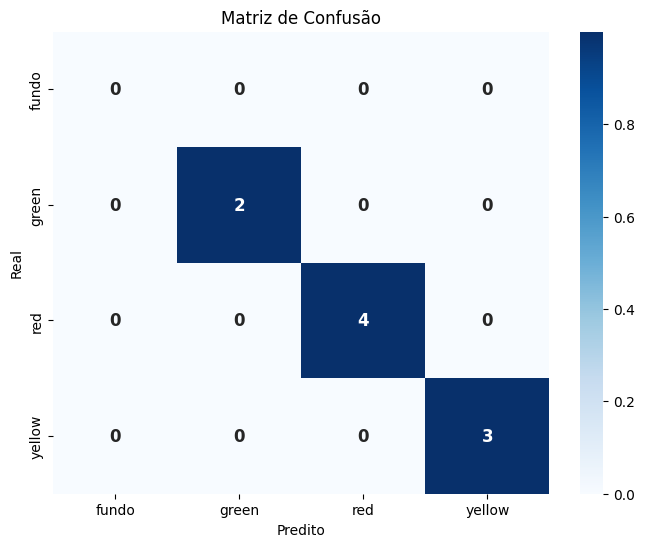

In [25]:
def getMatrix(network, loader, save=None):
    network.model.eval()
    network.matrix.reset()

    with torch.no_grad():
        for imgs, targets, paths in loader:
            imgs    = [img.to(network.device) for img in imgs]
            targets = [{key: val.to(network.device) for key, val in tgt.items()} for tgt in targets]
            network.matrix.update(network.model(imgs), targets)

    plt.figure(figsize=(8, 6))
    network.matrix.plot(names=['fundo'] + [names[c] for c in sorted(names)])

    if save:
        plt.savefig(save, bbox_inches='tight')
        plt.close()

    return network.matrix.matrix


getMatrix(network, testLoader)
plt.show()

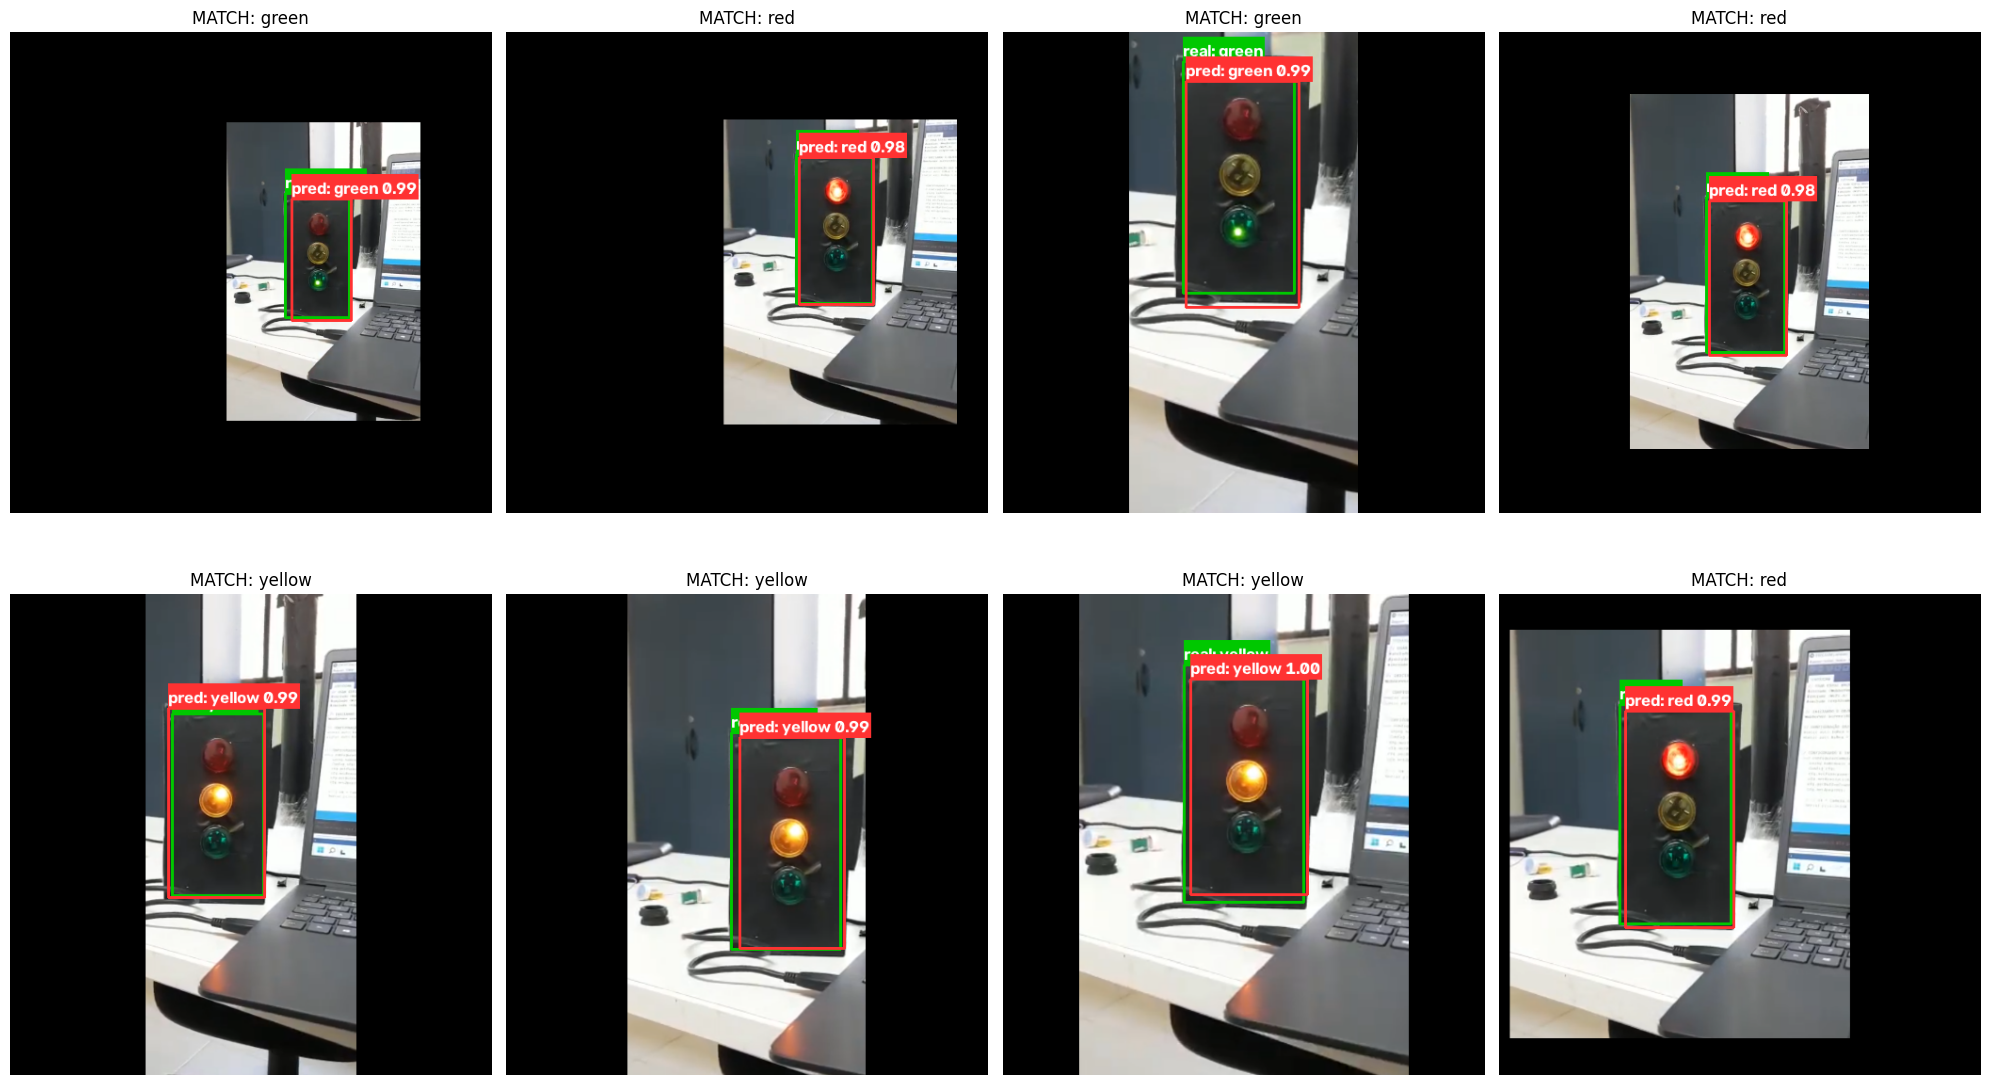

In [26]:
def plotPrediction(index, dataset=testDataset, network=network, save=None):
    network.model.eval()
    image, target, path = dataset[index]

    with torch.no_grad():
        output = network.model([image.to(network.device)])[0]

    keep = nms(output['boxes'], output['scores'], NMS_THRESHOLD)
    boxes, scores, labels = output['boxes'][keep], output['scores'][keep], output['labels'][keep]
    mask = scores >= SCORE_THRESHOLD

    pred_boxes  = boxes[mask].cpu().numpy()
    pred_scores = scores[mask].tolist()
    pred_labels = [names[value] for value in labels[mask].tolist()]
    gt_boxes    = target['boxes'].cpu().numpy()
    gt_labels   = [names[value] for value in target['labels'].tolist()]

    img = np.ascontiguousarray(image.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    for box, label in zip(gt_boxes, gt_labels):
        drawBox(img, box, f'real: {label}', (0, 200, 0))

    for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
        drawBox(img, box, f'pred: {label} {score:.2f}', (255, 50, 50))

    match = sorted(gt_labels) == sorted(pred_labels)
    plt.imshow(img)
    plt.title(f'MATCH: {", ".join(pred_labels)}' if match else f'DIVERGENTE: real {gt_labels} pred {pred_labels}')
    plt.axis('off')

    if save:
        os.makedirs(os.path.dirname(save), exist_ok=True)
        plt.savefig(save, dpi=130, bbox_inches='tight')
        return plt.close()


plt.figure(figsize=(20, 12))
for k in range(min(8, len(testDataset))):
    plt.subplot(2, 4, k + 1)
    plotPrediction(index=k)

plt.tight_layout()

# SALVANDO O MODELO

In [27]:
from datetime import datetime
import json

In [28]:
os.makedirs('Backup/', exist_ok=True)
files   = [path for path in os.listdir('Backup/') if path.startswith('model_')]
indexes = sorted([int(path.split('_')[-1]) for path in files]) if len(files) > 0 else [0]
index   = indexes[-1] + 1
folder  = f'Backup/model_{index}'
os.makedirs(folder, exist_ok=True)
folder

'Backup/model_5'

In [29]:
iouData = getClasses(network, testLoader, save=os.path.join(folder, 'classes.png'))
getMatrix(network, testLoader, save=os.path.join(folder, 'matrix.png'))

path = os.path.join(folder, 'predictions')
os.makedirs(path, exist_ok=True)

for i in range(min(len(testDataset), 15)):
    plotPrediction(index=i, save=os.path.join(path, f'pred_{i + 1}.png'))

In [30]:
model_info = {
    'trainer': {
        'path': f'model_{index}',
        'loss': selected_loss,
        'scheduler': scheduler,
        'epochs': trainer.epochs,
        'batch_size': OPTIONS.get('batch_size'),
        'val_iou': trainer.history[-1].get('val_iou'),
        'test_iou': test_iou,
    },

    'processing': OPTIONS,
    'model': model_options,
    'classes': classes,
    'iou': iouData,
}

model_data = {
    'model': network.model.state_dict(),
    'optimizer': network.optimizer.state_dict(),
    'timestamp': datetime.now().strftime('%d/%m/%y %H:%M:%S'),
    'history': trainer.history,
}

with open(f'{folder}/info.json', 'w', encoding='utf-8') as file:
    json.dump(model_info, file, ensure_ascii=False, indent=4)

plotModel(model_data['history'], save=os.path.join(folder, 'train.png'))
torch.save(model_data, f'{folder}/model.pth')
print('model saved in', folder)

model saved in Backup/model_5
